## 01 — Data Loading & Exploratory Data Analysis

### Dataset
The CICIDS2017 dataset contains approximately 2.8 million labelled network flows 
across 15 classes. It was selected over KDD Cup 99 due to its modern attack 
repertoire and relevance to contemporary network security contexts.

### Objectives
- Load and concatenate all daily CSV files into a single dataset
- Track the source file of each record for traceability
- Perform initial EDA to understand class distribution, feature types, and data quality

### Key Findings
- Severe class imbalance observed — BENIGN accounts for ~83% of records
- Infinite values present in several features (division-by-zero in flow calculations)
- [Add any others specific to what you found]

### Decisions Deferred
Fixes identified here (infinite values, column name whitespace) are documented 
but deferred to 02_data_preprocessing.ipynb in line with EDA-only discipline.

In [18]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import os

print(os.getcwd())

/Users/stans/eportfolio/eportfolio_Stanley-Southwick/network-anomaly-detector/notebooks


## 1.1 Loading & Combining the CICIDS2017 Dataset

The CICIDS2017 dataset is distributed across multiple daily CSV files. Rather than 
hardcoding individual file paths, all CSVs are discovered programmatically using 
`Path.glob()`, making the pipeline robust to changes in the number of source files.

A `source_file` column is added to each DataFrame before concatenation to preserve 
traceability — this allows any record to be traced back to its originating daily 
capture file, which is useful for debugging and auditing downstream.

All DataFrames are concatenated into a single `network_data` DataFrame with a 
reset index to ensure row indices are contiguous across the combined dataset.

In [19]:
path = Path("/Users/stans/eportfolio/eportfolio_Stanley-Southwick/network-anomaly-detector/data/raw").glob("*.csv") # List all CSV files in the raw data directory

# Loop through the CSV to concatenate them into a single DataFrame
dataframes = []
for csv_file in path:
    df = pd.read_csv(csv_file)
    df['source_file'] = csv_file.name  # Add a column to identify the source file
    dataframes.append(df)
# Concatenate all DataFrames into one
network_data = pd.concat(dataframes, ignore_index=True)



In [20]:
print(network_data.head())

    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22             166                   1   
1              60148              83                   1   
2                123           99947                   1   
3                123           37017                   1   
4                  0       111161336                 147   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            0   
1                        2                            0   
2                        1                           48   
3                        1                           48   
4                        0                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       0   
1                             0                       0   
2                            48                      48   
3                            48                 

In [21]:
print(network_data['source_file'].unique())

['Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
 'Monday-WorkingHours.pcap_ISCX.csv'
 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
 'Tuesday-WorkingHours.pcap_ISCX.csv'
 'Wednesday-workingHours.pcap_ISCX.csv'
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv']


In [22]:
print(network_data.shape)
print(network_data.info())

(2830743, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IA

#### Findings

 **Column name whitespace:** Leading and trailing whitespace was detected in several 
column names, causing silent failures when referencing columns by name. This will 
be resolved in `02_data_preprocessing.ipynb` by stripping whitespace from all 
column headers.

**Duplicate column:** `Fwd Header Length` and `Fwd Header Length.1` were found to 
be identical in both name (after deduplication) and values. One copy will be dropped 
in preprocessing as it carries no additional information.

Both issues are documented here but intentionally deferred — EDA is observation only.

In [23]:
# Remove whitespace in column names
network_data.columns = network_data.columns.str.strip()
# Check whitespace is removed
print(network_data.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [24]:
# Check if 'Fwd Header Length' and 'Fwd Header Length.1' are identical
print(network_data['Fwd Header Length'].equals(network_data['Fwd Header Length.1']))

True


In [25]:
print(network_data.isnull().sum()[network_data.isnull().sum() > 0])

Flow Bytes/s    1358
dtype: int64


#### Finding: Null Values

`Flow Bytes/s` contains 1,358 null values (~0.05% of the dataset). Given the small 
proportion, dropping these rows is the most defensible approach — imputation of 
network flow statistics risks introducing synthetic values into a security-sensitive 
dataset. Final decision deferred to `02_data_preprocessing.ipynb`.

In [26]:
print(network_data.duplicated().sum())

256479


#### Finding: Duplicate Rows

256,479 duplicate rows detected (~9% of the dataset). These will be dropped in 
`02_data_preprocessing.ipynb` — retaining duplicates would artificially inflate 
model performance by leaking identical records across train/test splits.

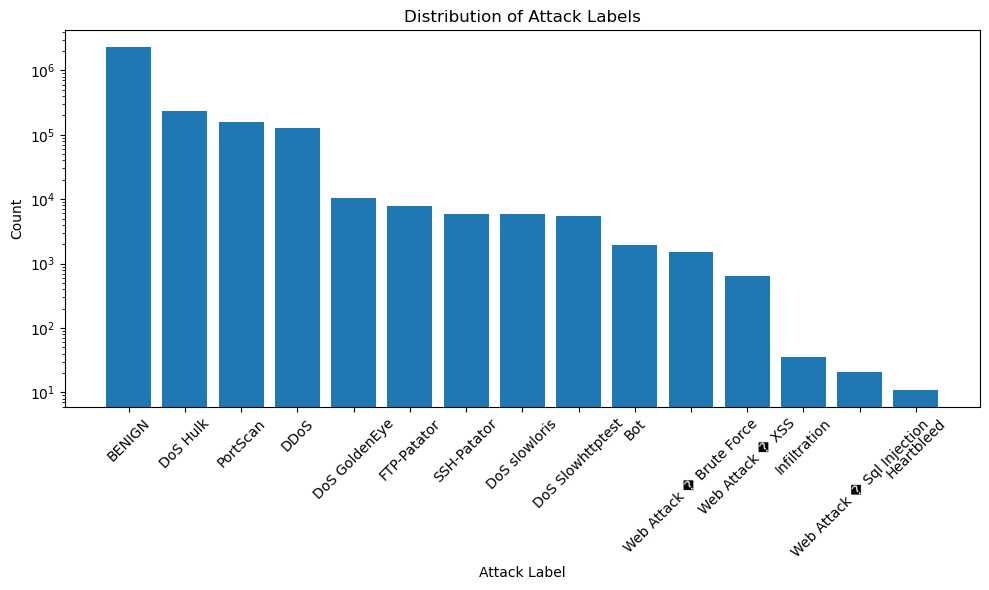

The dataset contains multiple different attacks types as follows: 
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
[2273097  231073  158930]


In [27]:
# Visualisation of attack label balance
counts = network_data['Label'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')  # Use logarithmic scale for better visibility of smaller classes
plt.title('Distribution of Attack Labels')
plt.xlabel('Attack Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Text summary 
print("The dataset contains multiple different attacks types as follows: \n"
      f"{network_data['Label'].value_counts()}")

print(counts.values[:3])

#### Finding: Class Imbalance & Encoding Issues

Class imbalance is severe — BENIGN accounts for the large majority of records. 
Rare classes (Heartbleed, SQL Injection, Infiltration) will require oversampling 
in `03_model_training.ipynb` using SMOTE with a programmatic sampling strategy.

Web Attack class labels contain character encoding errors (e.g. curly quotes or 
non-ASCII characters) which will be corrected during preprocessing in 
`02_data_preprocessing.ipynb`.



In [28]:
distribution_by_day = network_data.groupby('source_file')['Label'].value_counts().reset_index() 
distribution_by_day.columns = ['source_file', 'Label', 'count']
display(distribution_by_day)

,source_file,Label,count
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,DDoS,128027
1,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN,97718
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,PortScan,158930
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,BENIGN,127537
4,Friday-WorkingHours-Morning.pcap_ISCX.csv,BENIGN,189067
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Bot,1966
6,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,529918
7,Thursday-WorkingHours-Afternoon-Infilteration....,BENIGN,288566
8,Thursday-WorkingHours-Afternoon-Infilteration....,Infiltration,36
9,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,BENIGN,168186


#### Finding: Attack Distribution by Day

The source file breakdown reveals a structured capture schedule:

- **Monday** — BENIGN traffic only
- **Tuesday** — BENIGN, FTP-Patator, SSH-Patator
- **Wednesday** — DoS variants (GoldenEye, Hulk, Slowhttptest, Slowloris), Heartbleed
- **Thursday** — Web Attacks (Brute Force, SQL Injection, XSS), Infiltration
- **Friday (AM)** — Bot
- **Friday (PM)** — DDoS, PortScan

Heartbleed is concentrated exclusively on Wednesday and Infiltration on Thursday 
afternoon — both are extremely rare classes. This temporal concentration means a 
naive random train/test split risks placing all instances of a rare class in either 
train or test, making stratified splitting essential in `02_data_preprocessing.ipynb`.

In [29]:
# Check for no variance in numeric columns
no_variance = network_data.var(numeric_only=True) == 0
print("Columns with no variance:")
print(no_variance[no_variance].index.tolist())


Columns with no variance:
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


#### Finding: Zero Variance Features

8 features identified with zero variance — `Bwd PSH Flags`, `Bwd URG Flags`, 
`Fwd Avg Bytes/Bulk`, `Fwd Avg Packets/Bulk`, `Fwd Avg Bulk Rate`, 
`Bwd Avg Bytes/Bulk`, `Bwd Avg Packets/Bulk`, `Bwd Avg Bulk Rate`. These carry 
no discriminative information and will be dropped in `02_data_preprocessing.ipynb`.

In [30]:
# Check for infinite values in numeric columns
is_infinite_float = np.isinf(network_data.select_dtypes(include=[float])).sum()
print("Columns with infinite values:")
print(is_infinite_float[is_infinite_float > 0])

Columns with infinite values:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


#### Finding: Infinite Values

Two features contain infinite values:

- `Flow Bytes/s` — 1,509 infinite values (also contains 1,358 nulls noted above)
- `Flow Packets/s` — 2,867 infinite values

These are likely division-by-zero artefacts from CICFlowMeter during flow feature 
generation. Given the security-sensitive context, these records will be dropped in 
`02_data_preprocessing.ipynb` rather than imputed — injecting synthetic values into 
network flow statistics is difficult to justify in a security domain.

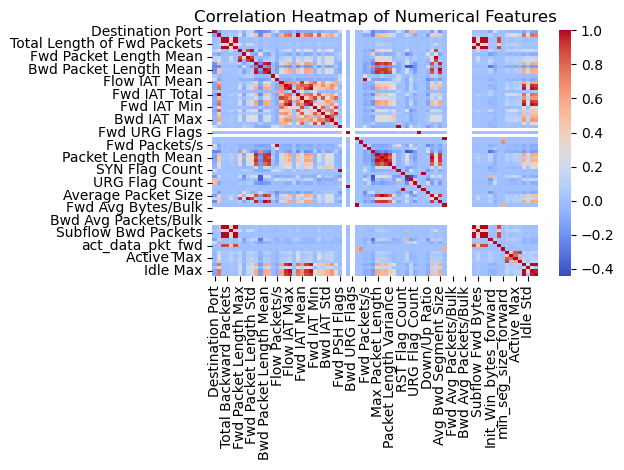

In [31]:
correlations = network_data.select_dtypes(include='number').corr()
sns.heatmap(correlations, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#### Finding: Feature Correlation

The correlation heatmap reveals clusters of high correlation, particularly among 
packet length and inter-arrival time (IAT) features. A threshold of ±0.95 will be 
used to identify and remove redundant feature pairs in `02_data_preprocessing.ipynb`, 
retaining one feature from each highly correlated pair to reduce dimensionality 
without information loss.

In [32]:
threshold = 0.95
high_corr = (correlations.abs() > threshold) & (correlations.abs() < 1.0)
pairs = [(col, row) for col in correlations.columns 
         for row in correlations.index 
         if high_corr.loc[row, col] and row < col]
print(f"Highly correlated pairs (>{threshold}):")
for pair in pairs:
    print(f"{pair[0]} -- {pair[1]}: {correlations.loc[pair[1], pair[0]]:.2f}")

Highly correlated pairs (>0.95):
Total Fwd Packets -- Total Backward Packets: 1.00
Total Fwd Packets -- Subflow Bwd Packets: 1.00
Total Fwd Packets -- Subflow Bwd Bytes: 1.00
Total Backward Packets -- Subflow Fwd Packets: 1.00
Total Backward Packets -- Subflow Bwd Bytes: 0.99
Total Length of Fwd Packets -- Subflow Fwd Bytes: 1.00
Total Length of Bwd Packets -- Total Fwd Packets: 1.00
Total Length of Bwd Packets -- Total Backward Packets: 0.99
Total Length of Bwd Packets -- Subflow Fwd Packets: 1.00
Total Length of Bwd Packets -- Subflow Bwd Packets: 0.99
Total Length of Bwd Packets -- Subflow Bwd Bytes: 1.00
Fwd Packet Length Std -- Fwd Packet Length Max: 0.97
Bwd Packet Length Max -- Avg Bwd Segment Size: 0.96
Bwd Packet Length Mean -- Bwd Packet Length Max: 0.96
Bwd Packet Length Mean -- Avg Bwd Segment Size: 1.00
Bwd Packet Length Std -- Bwd Packet Length Max: 0.98
Fwd IAT Total -- Flow Duration: 1.00
Fwd IAT Max -- Flow IAT Max: 1.00
Fwd Packets/s -- Flow Packets/s: 0.99
Packet Len

#### Finding: Highly Correlated Feature Pairs

33 feature pairs exceed the ±0.95 correlation threshold. Notable examples:

- `Subflow Fwd/Bwd Packets/Bytes` are near-perfect duplicates of `Total Fwd/Bwd 
  Packets` — Subflow features are redundant
- `Fwd IAT Total` and `Flow Duration` are perfectly correlated (1.00)
- `Packet Length Mean` and `Average Packet Size` are perfectly correlated (1.00)
- `Idle Mean`, `Idle Max`, `Idle Min` are all highly correlated with `Flow IAT Max`
- `RST Flag Count` and `ECE Flag Count` are perfectly correlated

A programmatic correlation threshold filter will be applied in 
`02_data_preprocessing.ipynb` to automatically drop one feature from each 
correlated pair, avoiding hardcoded column lists.

In [33]:
skewness = network_data.select_dtypes(include='number').skew()
print(skewness.sort_values(ascending=False).head(10))

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


Total Length of Fwd Packets    805.570539
Subflow Fwd Bytes              803.598592
act_data_pkt_fwd               284.595228
Total Backward Packets         244.679507
Subflow Bwd Packets            244.679507
Subflow Fwd Packets            244.380553
Total Fwd Packets              244.380553
Subflow Bwd Bytes              244.335301
Total Length of Bwd Packets    244.330893
CWE Flag Count                  94.781303
dtype: float64


In [34]:
skewness = network_data.select_dtypes(include='number').skew()
print(skewness.sort_values(ascending=True).head(10))

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


Fwd Header Length      -1325.073809
Fwd Header Length.1    -1325.073809
Bwd Header Length       -717.031304
min_seg_size_forward    -474.535265
Bwd PSH Flags              0.000000
Bwd Avg Bulk Rate          0.000000
Bwd Avg Packets/Bulk       0.000000
Bwd Avg Bytes/Bulk         0.000000
Fwd Avg Bulk Rate          0.000000
Fwd Avg Packets/Bulk       0.000000
dtype: float64


#### Finding: Feature Skewness

Several features exhibit severe right skew:

- `Total Length of Fwd Packets` (skewness: 805) and `Subflow Fwd Bytes` (803) are 
  extremely skewed — consistent with network traffic where most flows are small but 
  a few are very large
- Most of the top 10 skewed features are packet/byte count features, which is 
  expected behaviour for network flow data
- `Fwd Header Length` (skewness: -1,325) is also confirmed as a duplicate column 
  and will be dropped in `02_data_preprocessing.ipynb`
- `Bwd Header Length` (-717) and `min_seg_size_forward` (-474) are candidates for 
  log transformation

Extreme skewness can significantly hurt linear and distance-based models. As 
tree-based models (XGBoost, Random Forest) are the primary candidates here, this 
is less critical — however `log1p` transformation will be applied to heavily skewed 
features in preprocessing as good practice.

# Summary

The dataabse chosen 'CIDIDS2017' contains 2.8 million rows and is sperated across 8 files for different times of the working weeks representing 5 days of enwtork traffic with 14 different attack types and 79 feature.

## What has been done:
- Concanated the CSVs together and created the source file column for reference and further undsteranding of specific days.
- Checked the overview of the data using head, unique, shape, info which led to finding of excess whitespace and duplicate columns
- Removed the whitespace using strip method and double-checked the Fwd header columns were duplicates using equal method
- Checked the dataset for null value in regards to each column and duplicate rows.
- Checked the imbalance and distribution of attacks labels using visualisation 
- Checked the distribution on attacks on each day (source file) to look for patterns
- Checked for columns with 0 variance and infinite values
- Created a heatmap and list of pairs highly correlated to be dropped in preprocessing
- Finally checked the skewness of each features

## Findings:
- After initial EDA it was found that whitespace was affecting my search for columns or stripped the leading whitespace and Fwd Header Length and Fwd Header Length.1 column were identical and are to be removed in preprocessing stage.

- Flow Bytes/s has 1358 null values (0.05% of rows). Strategy to decide in preprocessing — likely safe to drop or impute given the small number.

- 256,479 duplicate rows (9% of dataset). These should be dropped in preprocessing before modelling — keeping them would artificially inflate model performance metrics.

- Class imbalance is sever to Benign. Rare classes are: heartbleed, SQL Injection and Infiltration which need to be oversampled or grouped in preprocessing. Web attack have character encoding errors which also need to be correted.

- This distribution of attacks by day has shown us a lot. 
    - Monday is normal traffic.
    - Tuesday - Normal and FTP/ SSh
    - Wednesday - All DOS attacks
    - Thursday - All web attacks 
    - Friday - Morning - Bot attacks
    - Friday - Afternoon - DDoS and PortScan

Rare attacks concetrated for heartbleed on Wednesday and Infiltration on Thursday afternoon - something to take note for train/ test splitting 

- 8 zero variance columns identified — Bwd PSH Flags, Bwd URG Flags, 
Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk, Fwd Avg Bulk Rate, Bwd Avg Bytes/Bulk, 
Bwd Avg Packets/Bulk, Bwd Avg Bulk Rate. Drop in preprocessing.

- Two columns contain infinite values:
    - Flow Bytes/s: 1509 infinite values (also has 1358 nulls)
    - Flow Packets/s: 2867 infinite values
These are likely division by zero artefacts from CICFlowMeter during feature generation.
Replace with NaN and impute in preprocessing.

- Heatmap shows key areas of high orrelation especially in the packet legnth and IAt features
Dive in further to find highly correlated pairs of a threshold of +/- 0.95

- 33 feature pairs with correlation > +/- 0.95 identified.
Notable examples:
    - Subflow Fwd/Bwd Packets/Bytes are near-perfect duplicates of Total Fwd/Bwd Packets — 
  Subflow features are redundant
    - Fwd IAT Total and Flow Duration are perfectly correlated (1.00) — one can be dropped
    - Packet Length Mean and Average Packet Size are perfectly correlated (1.00) — duplicates
    - Idle Mean, Idle Max, Idle Min are all highly correlated with Flow IAT Max
    - RST Flag Count and ECE Flag Count perfectly correlated — one is redundant
    In preprocessing, apply a correlation threshold filter to automatically 
    remove one feature from each highly correlated pair.

- Several features are severely right-skewed:
    - Total Length of Fwd Packets (805) and Subflow Fwd Bytes (803) are extremely skewed
    - Most of the top 10 are packet/byte count features — expected in network traffic data
    where most flows are small but a few are very large
    - Skewness this extreme can hurt linear models and distance-based models significantly
    Fwd Header Length (-1325) — also a duplicate column, drop in preprocessing
    - Bwd Header Length (-717) and min_seg_size_forward (-474) 
    are candidates for transformation in preprocessing
    
    Apply log transformation (log1p) to heavily skewed features in preprocessing.
Note: Tree-based models (XGBoost, Random Forest) are less sensitive to skewness.